In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from pybaseball import statcast, statcast_pitcher, playerid_lookup, playerid_reverse_lookup


In [7]:
data = pd.read_csv('pitcher_data.csv')
data['game_date'] = pd.to_datetime(data['game_date'])
data['year'] = data['game_date'].dt.year

ids = data['pitcher'].unique().tolist()
lookup = playerid_reverse_lookup(ids)
lookup

Gathering player lookup table. This may take a moment.


,name_last,name_first,key_mlbam,key_retro,key_bbref,key_fangraphs,mlb_played_first,mlb_played_last
0,crochet,garrett,676979,crocg001,crochga01,27463,2020.0,2025.0
1,kershaw,clayton,477132,kersc001,kershcl01,2036,2008.0,2025.0
2,miller,mason,695243,millm004,millema03,31757,2023.0,2025.0
3,verlander,justin,434378,verlj001,verlaju01,8700,2005.0,2025.0
4,burnes,corbin,669203,burnc002,burneco01,19361,2018.0,2025.0
5,darvish,yu,506433,darvy001,darviyu01,13074,2012.0,2025.0
6,scherzer,max,453286,schem001,scherma01,3137,2008.0,2025.0
7,sale,chris,519242,salec001,salech01,10603,2010.0,2025.0
8,cole,gerrit,543037,coleg001,colege01,13125,2013.0,2024.0


In [8]:
lookup['pitcher_name'] = lookup['name_first'] + ' ' + lookup['name_last']
data['pitcher_name'] = data['pitcher'].map(lookup.set_index('key_mlbam')['pitcher_name'])

In [9]:
data.head()

,game_date,pitcher,pitch_type,pitch_name,release_speed,release_spin_rate,pfx_x,pfx_z,release_pos_x,release_pos_z,release_extension,spin_axis,year,pitcher_name
0,2020-07-24,434378,FF,4-Seam Fastball,95.3,2523.0,-1.02,1.68,-1.71,6.80,6.1,210.0,2020,justin verlander
1,2020-07-24,434378,FF,4-Seam Fastball,93.4,2444.0,-0.96,1.72,-1.69,6.74,6.4,210.0,2020,justin verlander
2,2020-07-24,434378,FF,4-Seam Fastball,93.3,2466.0,-0.98,1.64,-1.78,6.85,6.2,210.0,2020,justin verlander
3,2020-07-24,434378,SL,Slider,85.7,2404.0,0.53,0.64,-1.94,6.73,6.1,184.0,2020,justin verlander
4,2020-07-24,434378,SL,Slider,85.0,2491.0,0.61,0.86,-1.85,6.81,6.1,195.0,2020,justin verlander


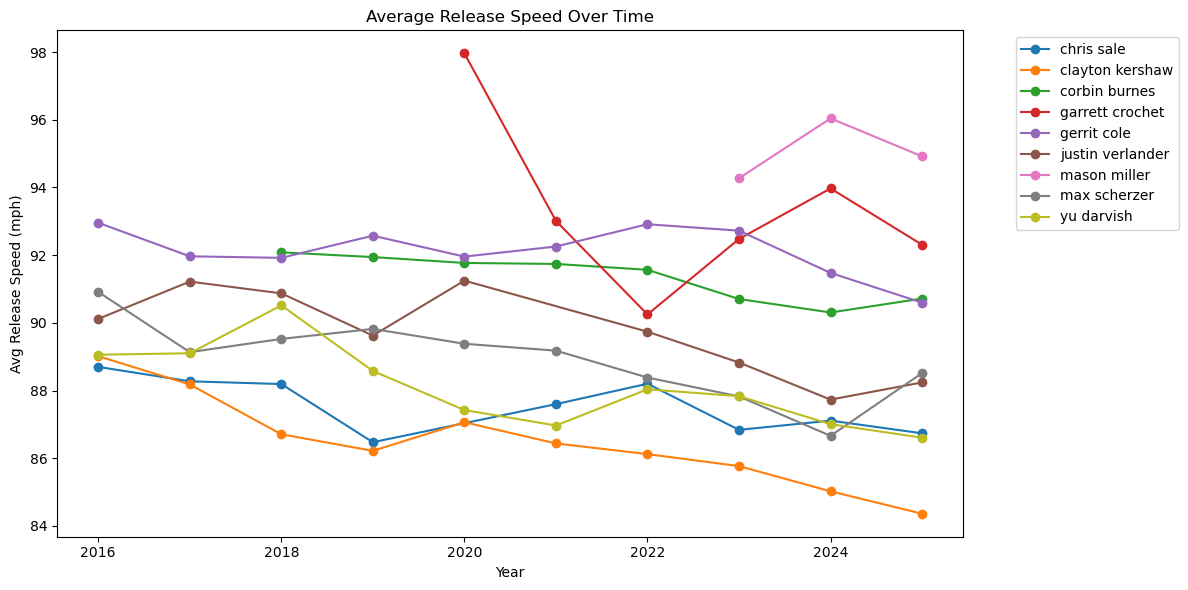

In [22]:
yearly_avg = data.groupby(['pitcher_name', 'year'])['release_speed'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
for name, group in yearly_avg.groupby('pitcher_name'):
    ax.plot(group['year'], group['release_speed'], marker='o', label=name)
ax.set_title('Average Release Speed Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Avg Release Speed (mph)')
ax.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [16]:
pitch_types_per_year = data.groupby(['pitcher_name', 'year'])['pitch_type'].nunique().reset_index()
pitch_types_per_year.columns = ['pitcher_name', 'year', 'num_pitch_types']
pitch_types_per_year

,pitcher_name,year,num_pitch_types
0,chris sale,2016,3
1,chris sale,2017,4
2,chris sale,2018,4
3,chris sale,2019,4
4,chris sale,2021,4
...,...,...,...
70,yu darvish,2021,9
71,yu darvish,2022,9
72,yu darvish,2023,10
73,yu darvish,2024,9


In [18]:
avg_pitch_types = pitch_types_per_year.groupby('pitcher_name')['num_pitch_types'].mean().reset_index()
avg_pitch_types

,pitcher_name,num_pitch_types
0,chris sale,3.888889
1,clayton kershaw,5.400000
2,corbin burnes,6.125000
3,garrett crochet,4.333333
4,gerrit cole,5.600000
5,justin verlander,5.000000
6,mason miller,3.666667
7,max scherzer,5.100000
8,yu darvish,9.500000
